# Proyek Analisis Data: E-Commerce Public Dataset (Olist)

- **Nama:** Rafa Al Razzak
- **Email:** rafaalrazzak@gmail.com
- **Dataset:** [E-Commerce Public Dataset](https://drive.google.com/file/d/1MsAjPM7oKtVfJL_wRp1qmCajtSG1mdcK/view?usp=sharing) - Brazilian E-Commerce (Olist)

## Menentukan Pertanyaan Bisnis

1. **Bagaimana tren jumlah pesanan dan revenue bulanan platform Olist sepanjang periode data (2016-2018), dan pada periode apa terjadi penurunan performa paling signifikan?**
   *(Specific: fokus pada tren order & revenue bulanan; Measurable: dihitung dari order_count & revenue per bulan; Action-oriented: hasilnya bisa dipakai untuk investigasi penyebab penurunan; Relevant: performa penjualan adalah inti bisnis; Time-bound: periode 2016-2018)*
2. **Kategori produk apa yang menyumbang revenue tertinggi dan terendah sepanjang periode data, sebagai dasar prioritas stok dan promosi?**
   *(Specific: fokus kategori produk; Measurable: diukur dari total revenue per kategori; Action-oriented: dasar keputusan stok/promosi; Relevant: alokasi budget marketing/inventory; Time-bound: sepanjang periode data yang tersedia)*
3. **Bagaimana sebaran jumlah pelanggan Olist berdasarkan negara bagian (state) di Brazil, dan 5 negara bagian mana yang paling berpotensi untuk ekspansi pemasaran?**
   *(Specific: fokus distribusi geografis pelanggan; Measurable: dihitung dari jumlah unique customer per state; Action-oriented: dasar target ekspansi kampanye regional; Relevant: strategi pertumbuhan pasar; Time-bound: kondisi pelanggan sepanjang data historis)*
4. **Bagaimana segmentasi pelanggan Olist berdasarkan Recency, Frequency, dan Monetary (RFM), dan berapa proporsi pelanggan pada tiap segmen untuk menentukan strategi retensi?**
   *(Specific: fokus segmentasi pelanggan via RFM; Measurable: dihitung dari skor RFM tiap customer; Action-oriented: dasar strategi retention/reward per segmen; Relevant: customer retention adalah prioritas bisnis e-commerce; Time-bound: dihitung relatif terhadap tanggal transaksi terakhir pada dataset)*

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster

sns.set(style="dark")

## Data Wrangling

### Gathering Data

Dataset E-Commerce Public Dataset (Olist) terdiri dari beberapa tabel yang saling berelasi. Seluruh berkas CSV diletakkan pada folder `data/`.

In [2]:
customers_df = pd.read_csv("data/customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [3]:
orders_df = pd.read_csv("data/orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
order_items_df = pd.read_csv("data/order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
order_payments_df = pd.read_csv("data/order_payments_dataset.csv")
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [6]:
order_reviews_df = pd.read_csv("data/order_reviews_dataset.csv")
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [7]:
products_df = pd.read_csv("data/products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [8]:
sellers_df = pd.read_csv("data/sellers_dataset.csv")
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [9]:
category_translation_df = pd.read_csv("data/product_category_name_translation.csv")
category_translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [10]:
geolocation_df = pd.read_csv("data/geolocation_dataset.csv")
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


### Assessing Data

#### Menilai tabel `customers_df`

In [11]:
customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB


In [12]:
print("Jumlah duplikasi: ", customers_df.duplicated().sum())

Jumlah duplikasi:  0


In [13]:
customers_df.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [14]:
customers_df.describe(include='all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


**Insight:** Tabel `customers_df` tidak memiliki missing value maupun data duplikat. Tidak ada masalah kualitas data pada tabel ini.

#### Menilai tabel `orders_df`

In [15]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


In [16]:
print("Jumlah duplikasi: ", orders_df.duplicated().sum())

Jumlah duplikasi:  0


In [17]:
orders_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [18]:
orders_df.order_status.value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

**Insight:** Ditemukan 2 masalah kualitas data pada tabel `orders_df`:
1. **Missing value** pada `order_approved_at` (160), `order_delivered_carrier_date` (1.783), dan `order_delivered_customer_date` (2.965) - wajar terjadi karena order tersebut belum/tidak sampai pada tahap tersebut (status `canceled`, `unavailable`, `processing`, dsb).
2. **Invalid/inconsistent value**: kolom tanggal (`order_purchase_timestamp`, dst) masih bertipe `object` (string), seharusnya `datetime`.

Solusi: konversi kolom tanggal ke tipe `datetime` pada tahap Cleaning Data. Missing value pada tanggal delivery dibiarkan (bukan error, melainkan representasi order yang belum terkirim) namun tidak dipakai pada analisis yang membutuhkan tanggal tersebut.

#### Menilai tabel `order_items_df`

In [19]:
order_items_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 18.4 MB


In [20]:
print("Jumlah duplikasi: ", order_items_df.duplicated().sum())

Jumlah duplikasi:  0


In [21]:
order_items_df.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [22]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


#### Menilai tabel `products_df`

In [23]:
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 3.7 MB


In [24]:
print("Jumlah duplikasi: ", products_df.duplicated().sum())

Jumlah duplikasi:  0


In [25]:
products_df.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

**Insight:** Ditemukan **missing value** pada `product_category_name` dan atribut produk lain (610 baris). Solusi: isi `product_category_name` yang kosong dengan label `"unknown"` agar tetap bisa diikutsertakan dalam agregasi kategori, tanpa membuang barisnya (karena `order_items_df` yang terhubung ke baris ini tetap valid).

#### Menilai tabel `order_payments_df`

In [26]:
order_payments_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 8.1 MB


In [27]:
print("Jumlah duplikasi: ", order_payments_df.duplicated().sum())

Jumlah duplikasi: 

 0


In [28]:
order_payments_df.isna().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

#### Menilai tabel `order_reviews_df`

In [29]:
order_reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 17.8 MB


In [30]:
order_reviews_df.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

**Insight:** `review_comment_title` dan `review_comment_message` memiliki banyak missing value - wajar karena pelanggan tidak wajib menulis komentar saat memberi skor review. Kolom ini tidak dipakai dalam analisis sehingga tidak perlu dibersihkan.

### Cleaning Data

#### Membersihkan tabel `orders_df`

##### Memperbaiki tipe data

In [31]:
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 13.0 MB


##### Duplicate data

In [32]:
orders_df.drop_duplicates(inplace=True)
customers_df.drop_duplicates(inplace=True)
print("Jumlah duplikasi orders_df: ", orders_df.duplicated().sum())
print("Jumlah duplikasi customers_df: ", customers_df.duplicated().sum())

Jumlah duplikasi orders_df:  0
Jumlah duplikasi customers_df:  0


#### Membersihkan tabel `products_df`

##### Missing values

In [33]:
products_df["product_category_name"] = products_df["product_category_name"].fillna("unknown")
products_df = products_df.merge(category_translation_df, on="product_category_name", how="left")
products_df["product_category_name_english"] = products_df["product_category_name_english"].fillna("unknown")
products_df.isna().sum()

product_id                         0
product_category_name              0
product_name_lenght              610
product_description_lenght       610
product_photos_qty               610
product_weight_g                   2
product_length_cm                  2
product_height_cm                  2
product_width_cm                   2
product_category_name_english      0
dtype: int64

## Exploratory Data Analysis (EDA)

### Explore `orders_df`

In [34]:
orders_df.order_status.value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [35]:
orders_df.resample(rule="ME", on="order_purchase_timestamp").order_id.nunique()

order_purchase_timestamp
2016-09-30       4
2016-10-31     324
2016-11-30       0
2016-12-31       1
2017-01-31     800
2017-02-28    1780
2017-03-31    2682
2017-04-30    2404
2017-05-31    3700
2017-06-30    3245
2017-07-31    4026
2017-08-31    4331
2017-09-30    4285
2017-10-31    4631
2017-11-30    7544
2017-12-31    5673
2018-01-31    7269
2018-02-28    6728
2018-03-31    7211
2018-04-30    6939
2018-05-31    6873
2018-06-30    6167
2018-07-31    6292
2018-08-31    6512
2018-09-30      16
2018-10-31       4
Freq: ME, Name: order_id, dtype: int64

### Explore `products_df` & `order_items_df`

In [36]:
order_items_products_df = order_items_df.merge(
    products_df[["product_id", "product_category_name_english"]],
    on="product_id",
    how="left"
)
order_items_products_df.groupby("product_category_name_english").agg(
    order_count=("order_id", "nunique"),
    revenue=("price", "sum")
).sort_values("revenue", ascending=False).head(10)

,order_count,revenue
product_category_name_english,,
health_beauty,8836,1258681.34
watches_gifts,5624,1205005.68
bed_bath_table,9417,1036988.68
sports_leisure,7720,988048.97
computers_accessories,6689,911954.32
furniture_decor,6449,729762.49
cool_stuff,3632,635290.85
housewares,5884,632248.66
auto,3897,592720.11


### Explore `customers_df`

**Catatan penting:** Pada dataset ini, `customer_id` bersifat **unik per pesanan** (1 pesanan baru = 1 `customer_id` baru), sedangkan `customer_unique_id` adalah identitas **pelanggan asli** yang bisa berulang di banyak pesanan. Untuk menghitung "jumlah pelanggan" yang benar (bukan jumlah pesanan), seluruh analisis pada notebook ini menggunakan `customer_unique_id`.

In [37]:
print("Jumlah baris (order-level):", customers_df.customer_id.nunique())
print("Jumlah pelanggan unik asli:", customers_df.customer_unique_id.nunique())
customers_df.groupby(by="customer_state").customer_unique_id.nunique().sort_values(ascending=False)

Jumlah baris (order-level): 99441
Jumlah pelanggan unik asli: 96096


customer_state
SP    40302
RJ    12384
MG    11259
RS     5277
PR     4882
SC     3534
BA     3277
DF     2075
ES     1964
GO     1952
PE     1609
CE     1313
PA      949
MT      876
MA      726
MS      694
PB      519
PI      482
RN      474
AL      401
SE      342
TO      273
RO      240
AM      143
AC       77
AP       67
RR       45
Name: customer_unique_id, dtype: int64

### Menggabungkan seluruh data menjadi satu dataframe utama

In [38]:
orders_clean_df = orders_df[orders_df["order_purchase_timestamp"].notna()]

all_df = order_items_products_df.merge(orders_clean_df, on="order_id", how="inner")
all_df = all_df.merge(customers_df, on="customer_id", how="left")

payment_per_order_df = order_payments_df.groupby("order_id").agg({"payment_value": "sum"}).reset_index()
all_df = all_df.merge(payment_per_order_df, on="order_id", how="left")

all_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,218.04


In [39]:
all_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  str           
 1   order_item_id                  112650 non-null  int64         
 2   product_id                     112650 non-null  str           
 3   seller_id                      112650 non-null  str           
 4   shipping_limit_date            112650 non-null  str           
 5   price                          112650 non-null  float64       
 6   freight_value                  112650 non-null  float64       
 7   product_category_name_english  112650 non-null  str           
 8   customer_id                    112650 non-null  str           
 9   order_status                   112650 non-null  str           
 10  order_purchase_timestamp       112650 non-null  datetime64[us]
 11  order_appro

### Explore `all_df`

In [40]:
monthly_orders_df = all_df.resample(rule="ME", on="order_purchase_timestamp").agg({
    "order_id": "nunique",
    "price": "sum"
}).reset_index()
monthly_orders_df.columns = ["order_month", "order_count", "revenue"]
monthly_orders_df

,order_month,order_count,revenue
0,2016-09-30,3,267.36
1,2016-10-31,308,49507.66
2,2016-11-30,0,0.00
3,2016-12-31,1,10.90
4,2017-01-31,789,120312.87
5,2017-02-28,1733,247303.02
6,2017-03-31,2641,374344.30
7,2017-04-30,2391,359927.23
8,2017-05-31,3660,506071.14
9,2017-06-30,3217,433038.60


In [41]:
cat_revenue_df = all_df.groupby("product_category_name_english").agg(
    order_count=("order_id", "nunique"),
    revenue=("price", "sum")
).sort_values("revenue", ascending=False)
cat_revenue_df

,order_count,revenue
product_category_name_english,,
health_beauty,8836,1258681.34
watches_gifts,5624,1205005.68
bed_bath_table,9417,1036988.68
sports_leisure,7720,988048.97
computers_accessories,6689,911954.32
...,...,...
flowers,29,1110.04
home_comfort_2,24,760.27
cds_dvds_musicals,12,730.00


In [42]:
state_customer_df = all_df.groupby("customer_state").customer_unique_id.nunique().sort_values(ascending=False).reset_index()
state_customer_df.columns = ["customer_state", "customer_count"]
state_customer_df

,customer_state,customer_count
0,SP,39981
1,RJ,12303
2,MG,11178
3,RS,5249
4,PR,4840
5,SC,3513
6,BA,3257
7,DF,2062
8,ES,1956
9,GO,1942


In [43]:
all_df.to_csv("main_data.csv", index=False)

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah pesanan dan revenue bulanan platform Olist, dan periode apa yang mengalami penurunan performa paling signifikan?

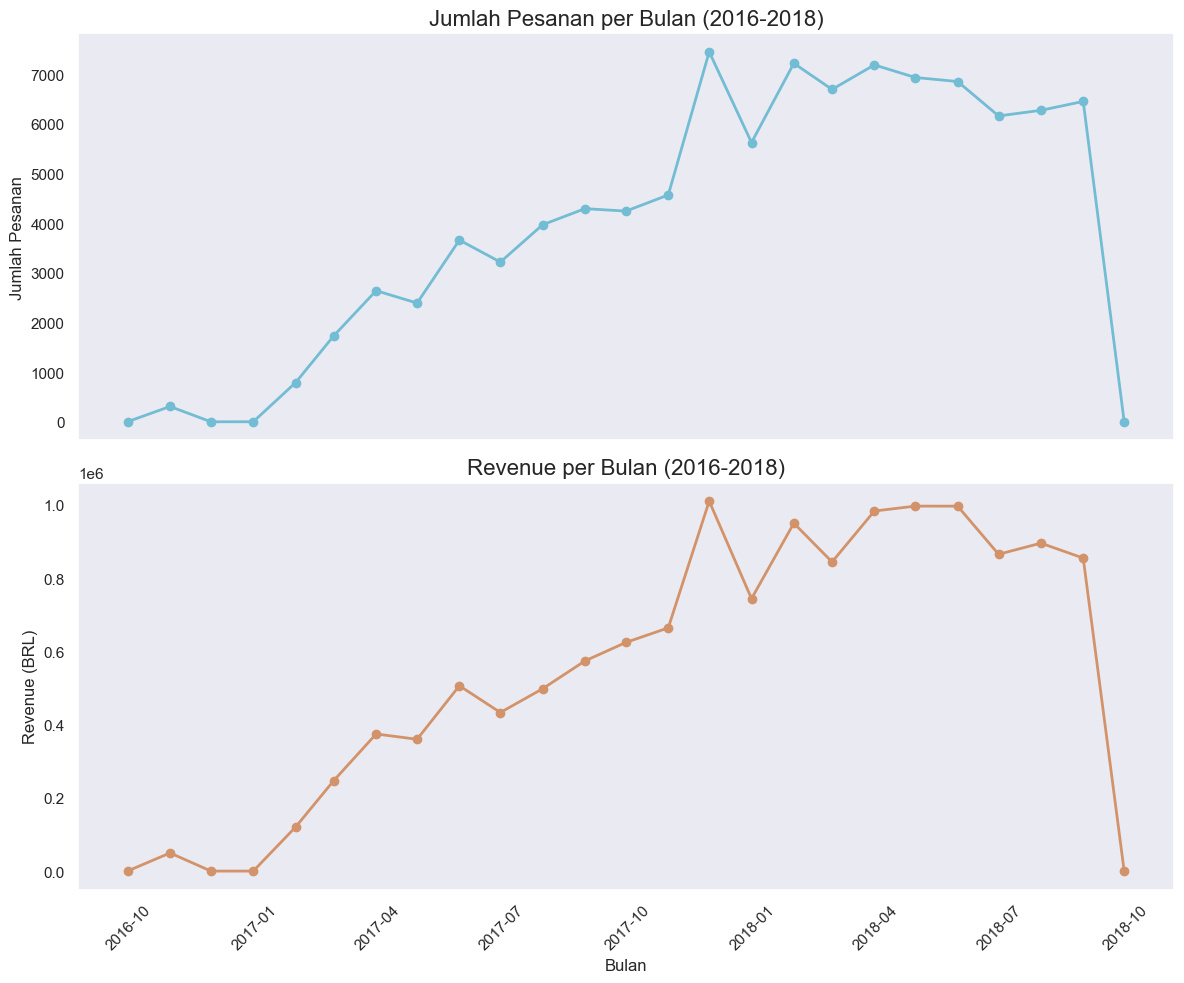

In [44]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)

ax[0].plot(
    monthly_orders_df["order_month"],
    monthly_orders_df["order_count"],
    marker="o",
    linewidth=2,
    color="#72BCD4"
)
ax[0].set_title("Jumlah Pesanan per Bulan (2016-2018)", fontsize=16)
ax[0].set_ylabel("Jumlah Pesanan")
ax[0].tick_params(axis="x", labelrotation=45)

ax[1].plot(
    monthly_orders_df["order_month"],
    monthly_orders_df["revenue"],
    marker="o",
    linewidth=2,
    color="#D3936A"
)
ax[1].set_title("Revenue per Bulan (2016-2018)", fontsize=16)
ax[1].set_ylabel("Revenue (BRL)")
ax[1].set_xlabel("Bulan")
ax[1].tick_params(axis="x", labelrotation=45)

plt.tight_layout()
plt.show()

**Insight:** Jumlah pesanan dan revenue tumbuh cepat sejak platform baru berjalan (September 2016) hingga mencapai puncaknya pada **November 2017** dengan 7.451 pesanan dan revenue BRL 1.010.271,37 (lonjakan tajam, selaras dengan periode Black Friday di Brazil), lalu memasuki fase **plateau/stabil** sepanjang 2018 (berkisar 6.160-7.220 pesanan/bulan) dengan sedikit penurunan pada paruh kedua 2018 (Juni-Agustus 2018) dibanding puncaknya. Bulan September 2016 (baru 3 pesanan) dan September 2018 (1 pesanan) tidak dianggap sebagai penurunan riil karena keduanya adalah **bulan tidak lengkap** (awal platform baru mulai beroperasi dan batas akhir periode pengumpulan data).

### Pertanyaan 2: Kategori produk apa yang menyumbang revenue tertinggi dan terendah?

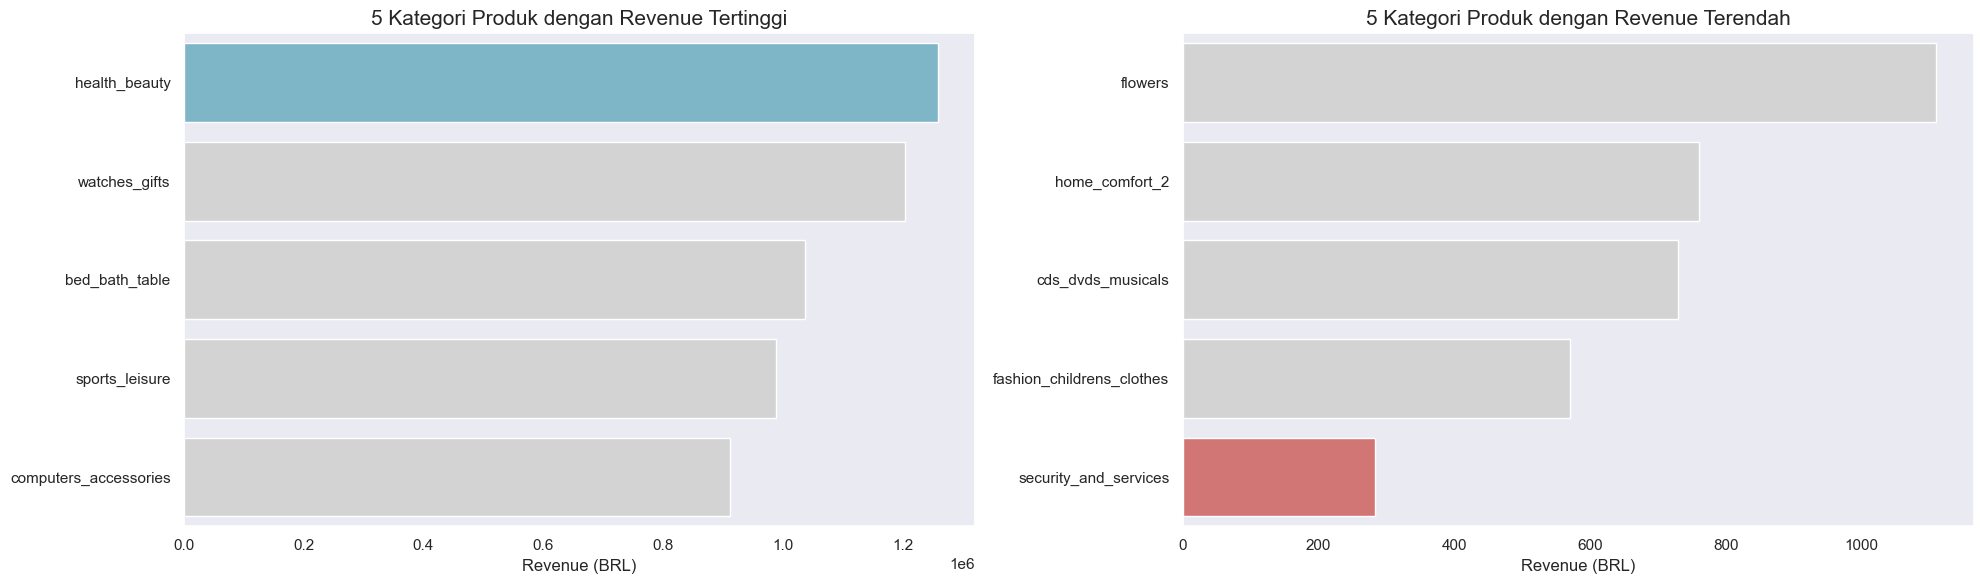

In [45]:
top_cat = cat_revenue_df.head(5).reset_index()
bottom_cat = cat_revenue_df.tail(5).reset_index()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

colors_top = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]
sns.barplot(x="revenue", y="product_category_name_english", hue="product_category_name_english", data=top_cat, palette=colors_top, legend=False, ax=ax[0])
ax[0].set_title("5 Kategori Produk dengan Revenue Tertinggi", fontsize=15)
ax[0].set_xlabel("Revenue (BRL)")
ax[0].set_ylabel(None)

colors_bottom = ["#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#E06666"]
sns.barplot(x="revenue", y="product_category_name_english", hue="product_category_name_english", data=bottom_cat, palette=colors_bottom, legend=False, ax=ax[1])
ax[1].set_title("5 Kategori Produk dengan Revenue Terendah", fontsize=15)
ax[1].set_xlabel("Revenue (BRL)")
ax[1].set_ylabel(None)

plt.tight_layout()
plt.show()

**Insight:** Kategori **health_beauty**, **watches_gifts**, dan **bed_bath_table** menyumbang revenue tertinggi, sementara kategori **fashion_childrens_clothes** dan **security_and_services** memiliki revenue terendah (kurang dari BRL 1.000 sepanjang periode data).

### Pertanyaan 3: Bagaimana sebaran pelanggan berdasarkan negara bagian, dan negara bagian mana yang paling potensial untuk ekspansi?

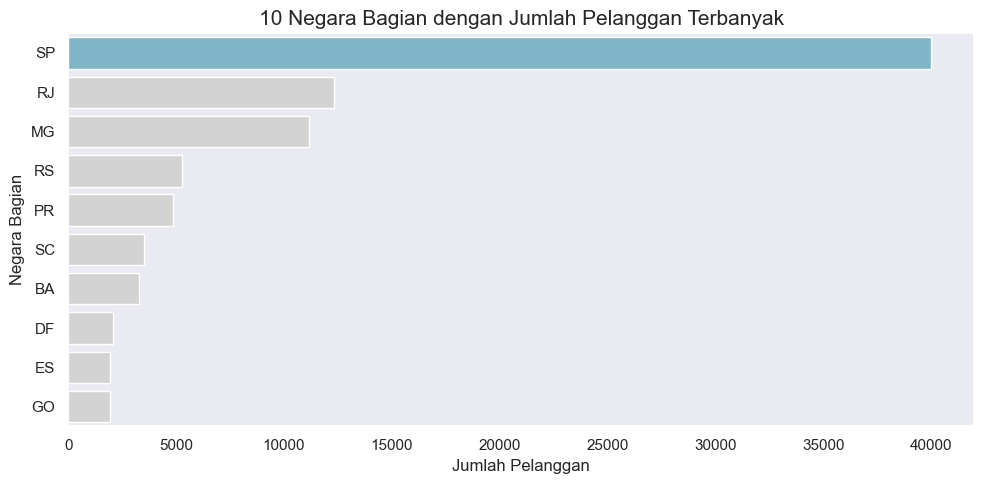

In [46]:
top10_state = state_customer_df.head(10)

plt.figure(figsize=(10, 5))
colors_state = ["#72BCD4"] + ["#D3D3D3"] * 9
sns.barplot(
    x="customer_count",
    y="customer_state",
    hue="customer_state",
    data=top10_state,
    palette=colors_state,
    legend=False
)
plt.title("10 Negara Bagian dengan Jumlah Pelanggan Terbanyak", fontsize=15)
plt.xlabel("Jumlah Pelanggan")
plt.ylabel("Negara Bagian")
plt.tight_layout()
plt.show()

In [47]:
geo_state_df = geolocation_df.groupby("geolocation_state").agg(
    lat=("geolocation_lat", "mean"),
    lng=("geolocation_lng", "mean")
).reset_index()

geo_state_df = geo_state_df.merge(state_customer_df, left_on="geolocation_state", right_on="customer_state", how="inner")

m = folium.Map(location=[-14.2, -51.9], zoom_start=4, tiles="OpenStreetMap")

for _, row in geo_state_df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=max(row["customer_count"] ** 0.5 / 12, 3),
        popup=f"{row['customer_state']}: {row['customer_count']:,} pelanggan",
        color="#72BCD4",
        fill=True,
        fill_color="#72BCD4",
        fill_opacity=0.6
    ).add_to(m)

m.save("peta_sebaran_pelanggan.html")
m

**Insight (Geospatial Analysis):** Pelanggan Olist terkonsentrasi sangat tinggi di wilayah **Sudeste** (Tenggara Brazil), terutama negara bagian **SP (Sao Paulo)** dengan 39.981 pelanggan unik - jauh di atas negara bagian lain - disusul **RJ (Rio de Janeiro)** dengan 12.303 pelanggan dan **MG (Minas Gerais)** dengan 11.178 pelanggan. Negara bagian di wilayah Utara/Barat memiliki pelanggan sangat sedikit. Negara bagian dengan jumlah pelanggan menengah namun masih jauh dari SP - seperti **RS** (5.249), **PR** (4.840), **SC** (3.513), **BA** (3.257), dan **DF** (2.062) - adalah kandidat paling realistis untuk ekspansi pemasaran, karena sudah memiliki basis pelanggan namun potensi pertumbuhannya masih besar dibanding SP yang sudah jenuh.

### Pertanyaan 4: Bagaimana segmentasi pelanggan berdasarkan RFM, dan berapa proporsi tiap segmen?

#### RFM Analysis

**Catatan:** RFM dihitung berdasarkan `customer_unique_id` (bukan `customer_id`), karena satu pelanggan asli bisa memiliki lebih dari satu `customer_id` (satu per pesanan). Jika dihitung dari `customer_id`, nilai *Frequency* akan selalu 1 untuk semua pelanggan dan analisis RFM menjadi tidak bermakna.

In [48]:
rfm_df = all_df.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": "max",  # mengambil tanggal order terakhir
    "order_id": "nunique",              # menghitung jumlah order (frequency)
    "price": "sum"                      # menghitung jumlah revenue (monetary)
})
rfm_df.columns = ["customer_unique_id", "max_order_timestamp", "frequency", "monetary"]

# menghitung kapan terakhir pelanggan melakukan transaksi (hari)
rfm_df["max_order_timestamp"] = rfm_df["max_order_timestamp"].dt.date
recent_date = all_df["order_purchase_timestamp"].dt.date.max()
rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)
rfm_df.drop("max_order_timestamp", axis=1, inplace=True)

rfm_df.head()

,customer_unique_id,frequency,monetary,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,116
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,119
2,0000f46a3911fa3c0805444483337064,1,69.00,542
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,326
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,293


In [49]:
rfm_df.describe()

,frequency,monetary,recency
count,95420.000000,95420.000000,95420.000000
mean,1.034018,142.440198,243.501457
std,0.211234,217.656355,153.160850
min,1.000000,0.850000,0.000000
25%,1.000000,47.900000,119.000000
50%,1.000000,89.900000,224.000000
75%,1.000000,155.000000,353.000000
max,16.000000,13440.000000,729.000000


#### Mengurutkan customer berdasarkan recency, frequency, & monetary score

In [50]:
rfm_df["r_rank"] = rfm_df["recency"].rank(ascending=False)
rfm_df["f_rank"] = rfm_df["frequency"].rank(ascending=True)
rfm_df["m_rank"] = rfm_df["monetary"].rank(ascending=True)

# normalizing the rank of the customers
rfm_df["r_rank_norm"] = (rfm_df["r_rank"] / rfm_df["r_rank"].max()) * 100
rfm_df["f_rank_norm"] = (rfm_df["f_rank"] / rfm_df["f_rank"].max()) * 100
rfm_df["m_rank_norm"] = (rfm_df["m_rank"] / rfm_df["m_rank"].max()) * 100

rfm_df["RFM_score"] = 0.15 * rfm_df["r_rank_norm"] + 0.28 * \
    rfm_df["f_rank_norm"] + 0.57 * rfm_df["m_rank_norm"]
rfm_df["RFM_score"] *= 0.05
rfm_df = rfm_df.round(2)
rfm_df[["customer_unique_id", "recency", "frequency", "monetary", "RFM_score"]].head()

,customer_unique_id,recency,frequency,monetary,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,129.90,3.17
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,18.90,1.37
2,0000f46a3911fa3c0805444483337064,542,1,69.00,1.83
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,25.99,1.18
4,0004aac84e0df4da2b147fca70cf8255,293,1,180.00,3.22


#### Segmentasi customer berdasarkan RFM_score

In [51]:
rfm_df["customer_segment"] = np.where(
    rfm_df["RFM_score"] > 4.5, "Top customers", np.where(
        rfm_df["RFM_score"] > 4, "High value customers", np.where(
            rfm_df["RFM_score"] > 3, "Medium value customers", np.where(
                rfm_df["RFM_score"] > 1.6, "Low value customers", "Lost customers"))))

customer_segment_df = rfm_df.groupby(by="customer_segment", as_index=False).customer_unique_id.nunique()
customer_segment_df.columns = ["customer_segment", "customer_count"]
customer_segment_df

,customer_segment,customer_count
0,High value customers,2574
1,Lost customers,18233
2,Low value customers,46088
3,Medium value customers,28033
4,Top customers,492


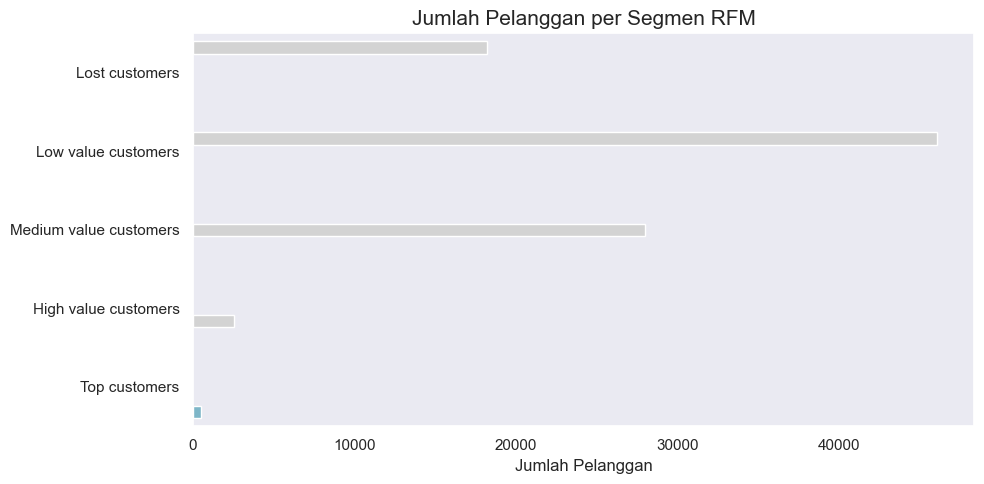

In [52]:
customer_segment_df["customer_segment"] = pd.Categorical(customer_segment_df["customer_segment"], [
    "Lost customers", "Low value customers", "Medium value customers",
    "High value customers", "Top customers"
])

plt.figure(figsize=(10, 5))
colors_segment = ["#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#72BCD4"]
sns.barplot(
    x="customer_count",
    y="customer_segment",
    hue="customer_segment",
    data=customer_segment_df.sort_values(by="customer_segment"),
    palette=colors_segment,
    legend=False
)
plt.title("Jumlah Pelanggan per Segmen RFM", fontsize=15)
plt.xlabel("Jumlah Pelanggan")
plt.ylabel(None)
plt.tight_layout()
plt.show()

**Insight (RFM Analysis):** Dari total 95.420 pelanggan unik yang tersegmentasi, mayoritas berada pada segmen **Low value customers** (46.088 pelanggan, 48,3%). Yang perlu jadi perhatian serius: segmen **Lost customers** (paling berisiko churn) ternyata cukup besar, yaitu 18.233 pelanggan (19,1%) - segmen terbesar kedua. Segmen **Medium value customers** berjumlah 28.033 pelanggan (29,4%), sedangkan segmen paling bernilai - **High value customers** (2.574 pelanggan, 2,7%) dan **Top customers** (492 pelanggan, 0,5%) - jumlahnya sangat kecil dibanding total basis pelanggan. Rata-rata pelanggan hanya bertransaksi 1,03 kali (`rfm_df.describe()`), namun ada pelanggan yang bertransaksi hingga 16 kali - menunjukkan sebagian kecil pelanggan sangat loyal di tengah mayoritas yang hanya membeli sesekali.

## Conclusion

- **Conclusion pertanyaan 1:** Tren jumlah pesanan dan revenue Olist tumbuh pesat dari peluncuran (September 2016) hingga puncaknya pada November 2017 (momentum Black Friday), lalu stabil (plateau) sepanjang 2018 dengan sedikit pelemahan di paruh kedua 2018. Tidak ada penurunan drastis yang perlu dikhawatirkan di luar efek bulan data tidak lengkap di awal dan akhir periode.
- **Conclusion pertanyaan 2:** Kategori **health_beauty**, **watches_gifts**, dan **bed_bath_table** adalah kontributor revenue terbesar dan layak diprioritaskan untuk stok & promosi, sementara kategori seperti **fashion_childrens_clothes** dan **security_and_services** memiliki kontribusi sangat kecil dan bisa dievaluasi ulang kelayakan investasinya.
- **Conclusion pertanyaan 3:** Pelanggan Olist sangat terkonsentrasi di wilayah Sudeste (SP, RJ, MG). Negara bagian seperti RS, PR, SC, BA, dan DF adalah kandidat ekspansi pemasaran paling realistis karena sudah memiliki basis pelanggan namun pasarnya belum sejenuh SP.
- **Conclusion pertanyaan 4:** Mayoritas pelanggan (95.420 pelanggan unik) berada di segmen Low-Medium value (77,7% gabungan), dan yang paling mengkhawatirkan: segmen **Lost customers** mencapai 19,1% (18.233 pelanggan) - churn rate yang cukup tinggi. Segmen paling bernilai (High value + Top customers) hanya 3,2% dari total basis pelanggan (3.066 pelanggan), sehingga sangat rentan jika tidak dijaga loyalitasnya.

### Rekomendasi Action Item

1. Alokasikan budget marketing tambahan untuk kampanye regional di RS, PR, SC, BA, dan DF (hasil geospatial analysis) untuk memperluas basis pelanggan di luar SP yang sudah jenuh.
2. Tingkatkan stok & promosi pada kategori health_beauty, watches_gifts, dan bed_bath_table, serta evaluasi ulang kelayakan kategori dengan revenue sangat rendah (fashion_childrens_clothes, security_and_services).
3. **Prioritas utama:** buat kampanye re-engagement (voucher/diskon khusus) untuk 18.233 pelanggan di segmen **Lost customers** karena jumlahnya signifikan (19,1% dari total pelanggan), serta program retention/reward eksklusif untuk 3.066 pelanggan di segmen **High value** & **Top customers** yang menyumbang revenue tidak proporsional terhadap jumlahnya yang kecil.
4. Investigasi mengapa mayoritas pelanggan (rata-rata frequency 1,03 kali) tidak kembali bertransaksi - misalnya lewat survei churn atau analisis funnel checkout - sebagai tindak lanjut dari temuan RFM Analysis.